# Level 2 – Task 2
## Price Range Analysis

### Objective

- Determine the most common price range among restaurants.
- Calculate the average Aggregate Rating for each price range.
- Identify the color that represents the highest average rating among different price ranges.
- Visualize the price range distribution and average ratings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../Outputs/zomato_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (9551, 21)


In [3]:
required_columns = ["Price range", "Aggregate rating", "Rating color"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


# Analyze Price Range distribution

In [4]:
price_range_counts = df["Price range"].value_counts().sort_index()

print("Restaurant count by Price Range:")
print(price_range_counts)

Restaurant count by Price Range:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


# Find the most common price range

In [5]:
most_common_price_range = price_range_counts.idxmax()
most_common_count = price_range_counts.max()

print("Most common price range:", most_common_price_range)
print("Number of restaurants:", most_common_count)

Most common price range: 1
Number of restaurants: 4444


# Visualize price range distribution

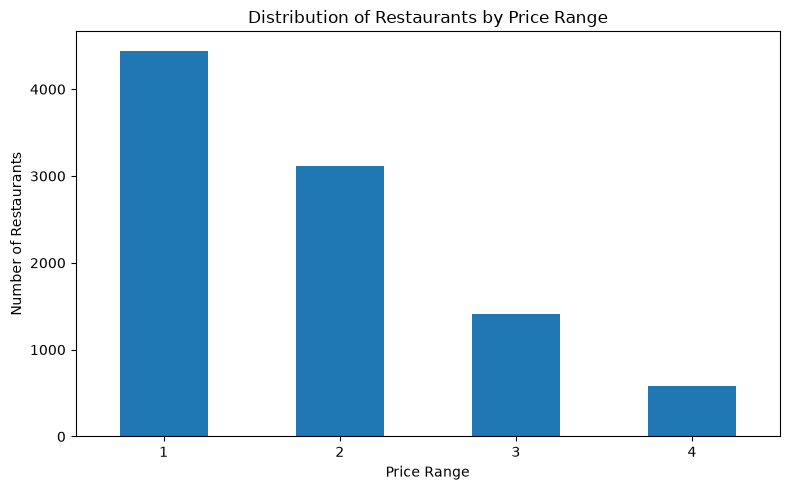

In [6]:
plt.figure(figsize=(8, 5))

price_range_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate average rating for each price range

In [7]:
average_rating_by_price = (
    df.groupby("Price range")["Aggregate rating"]
    .mean()
    .round(2)
)

print("Average Aggregate Rating by Price Range:")
print(average_rating_by_price)

Average Aggregate Rating by Price Range:
Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


# Visualize average rating

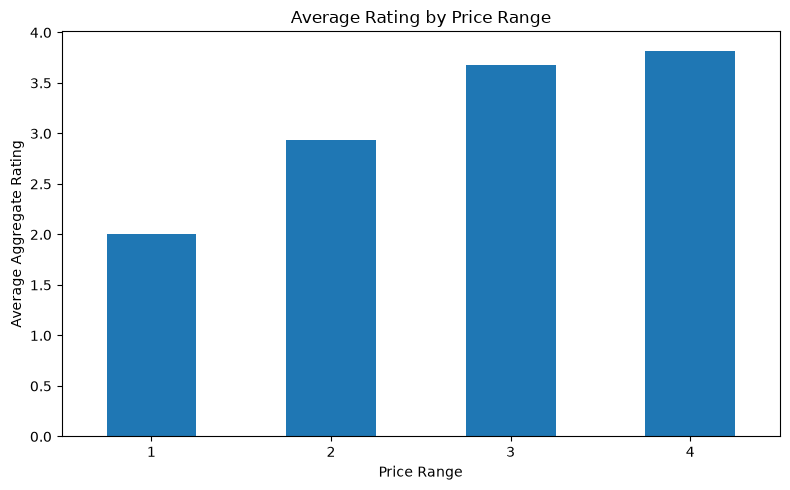

In [8]:
plt.figure(figsize=(8, 5))

average_rating_by_price.plot(kind="bar")

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify the color representing the highest average rating

In [9]:
price_color_analysis = (
    df.groupby(["Price range", "Rating color"])["Aggregate rating"]
    .mean()
    .reset_index()
)

price_color_analysis = price_color_analysis.sort_values(
    "Aggregate rating",
    ascending=False
)

print("Price Range, Rating Color and Average Rating:")
display(price_color_analysis)

Price Range, Rating Color and Average Rating:


,Price range,Rating color,Aggregate rating
18,4,Dark Green,4.709459
0,1,Dark Green,4.668750
12,3,Dark Green,4.646032
6,2,Dark Green,4.627536
19,4,Green,4.188144
13,3,Green,4.169231
7,2,Green,4.159385
1,1,Green,4.157639
17,3,Yellow,3.716265
23,4,Yellow,3.716000


# Find the highest-rated price range and its color

In [10]:
highest_rating_row = price_color_analysis.iloc[0]

print("Price range with highest average rating:",
      highest_rating_row["Price range"])

print("Rating color:",
      highest_rating_row["Rating color"])

print("Average rating:",
      round(highest_rating_row["Aggregate rating"], 2))

Price range with highest average rating: 4
Rating color: Dark Green
Average rating: 4.71


# Create a combined visualization

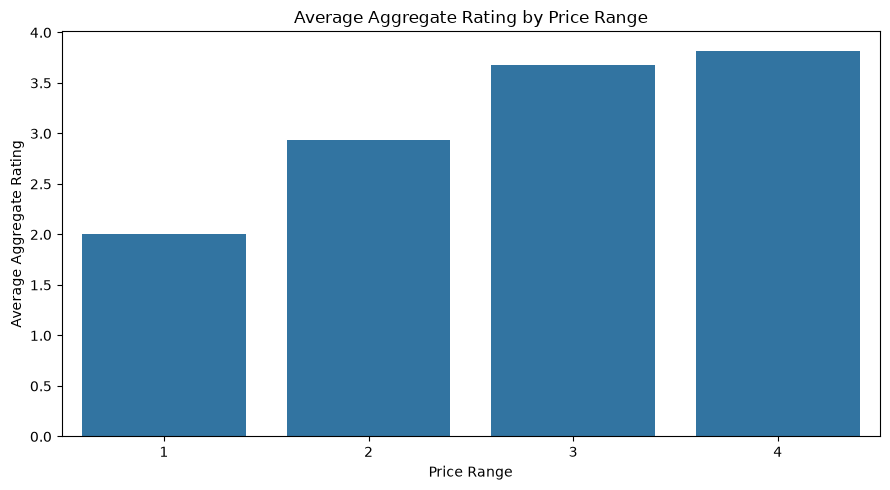

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=average_rating_by_price.index,
    y=average_rating_by_price.values
)

plt.title("Average Aggregate Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Aggregate Rating")
plt.tight_layout()
plt.show()

# output

In [12]:
price_range_counts.reset_index().rename(
    columns={"count": "Restaurant Count"}
).to_csv(
    "../Outputs/price_range_distribution.csv",
    index=False
)

average_rating_by_price.reset_index().rename(
    columns={"Aggregate rating": "Average Rating"}
).to_csv(
    "../Outputs/average_rating_by_price_range.csv",
    index=False
)

price_color_analysis.to_csv(
    "../Outputs/price_range_rating_color_analysis.csv",
    index=False
)

print("All Task 2 outputs saved successfully.")

All Task 2 outputs saved successfully.


# Conclusion

The Price Range Analysis examined restaurant distribution, average ratings, and rating colors across different price ranges.

- The most common price range was identified based on restaurant count.
- Average Aggregate Rating was calculated for each price range.
- The price range with the highest average rating was identified.
- The corresponding Rating Color was determined.
- Visualizations were created to communicate the findings clearly.